Loading geodatabase...
Applying analytical categorizations...
Cleaning geometries for static mapping...
Data saved to data\cleaned\alameda_master_full.parquet
Rendering static maps...


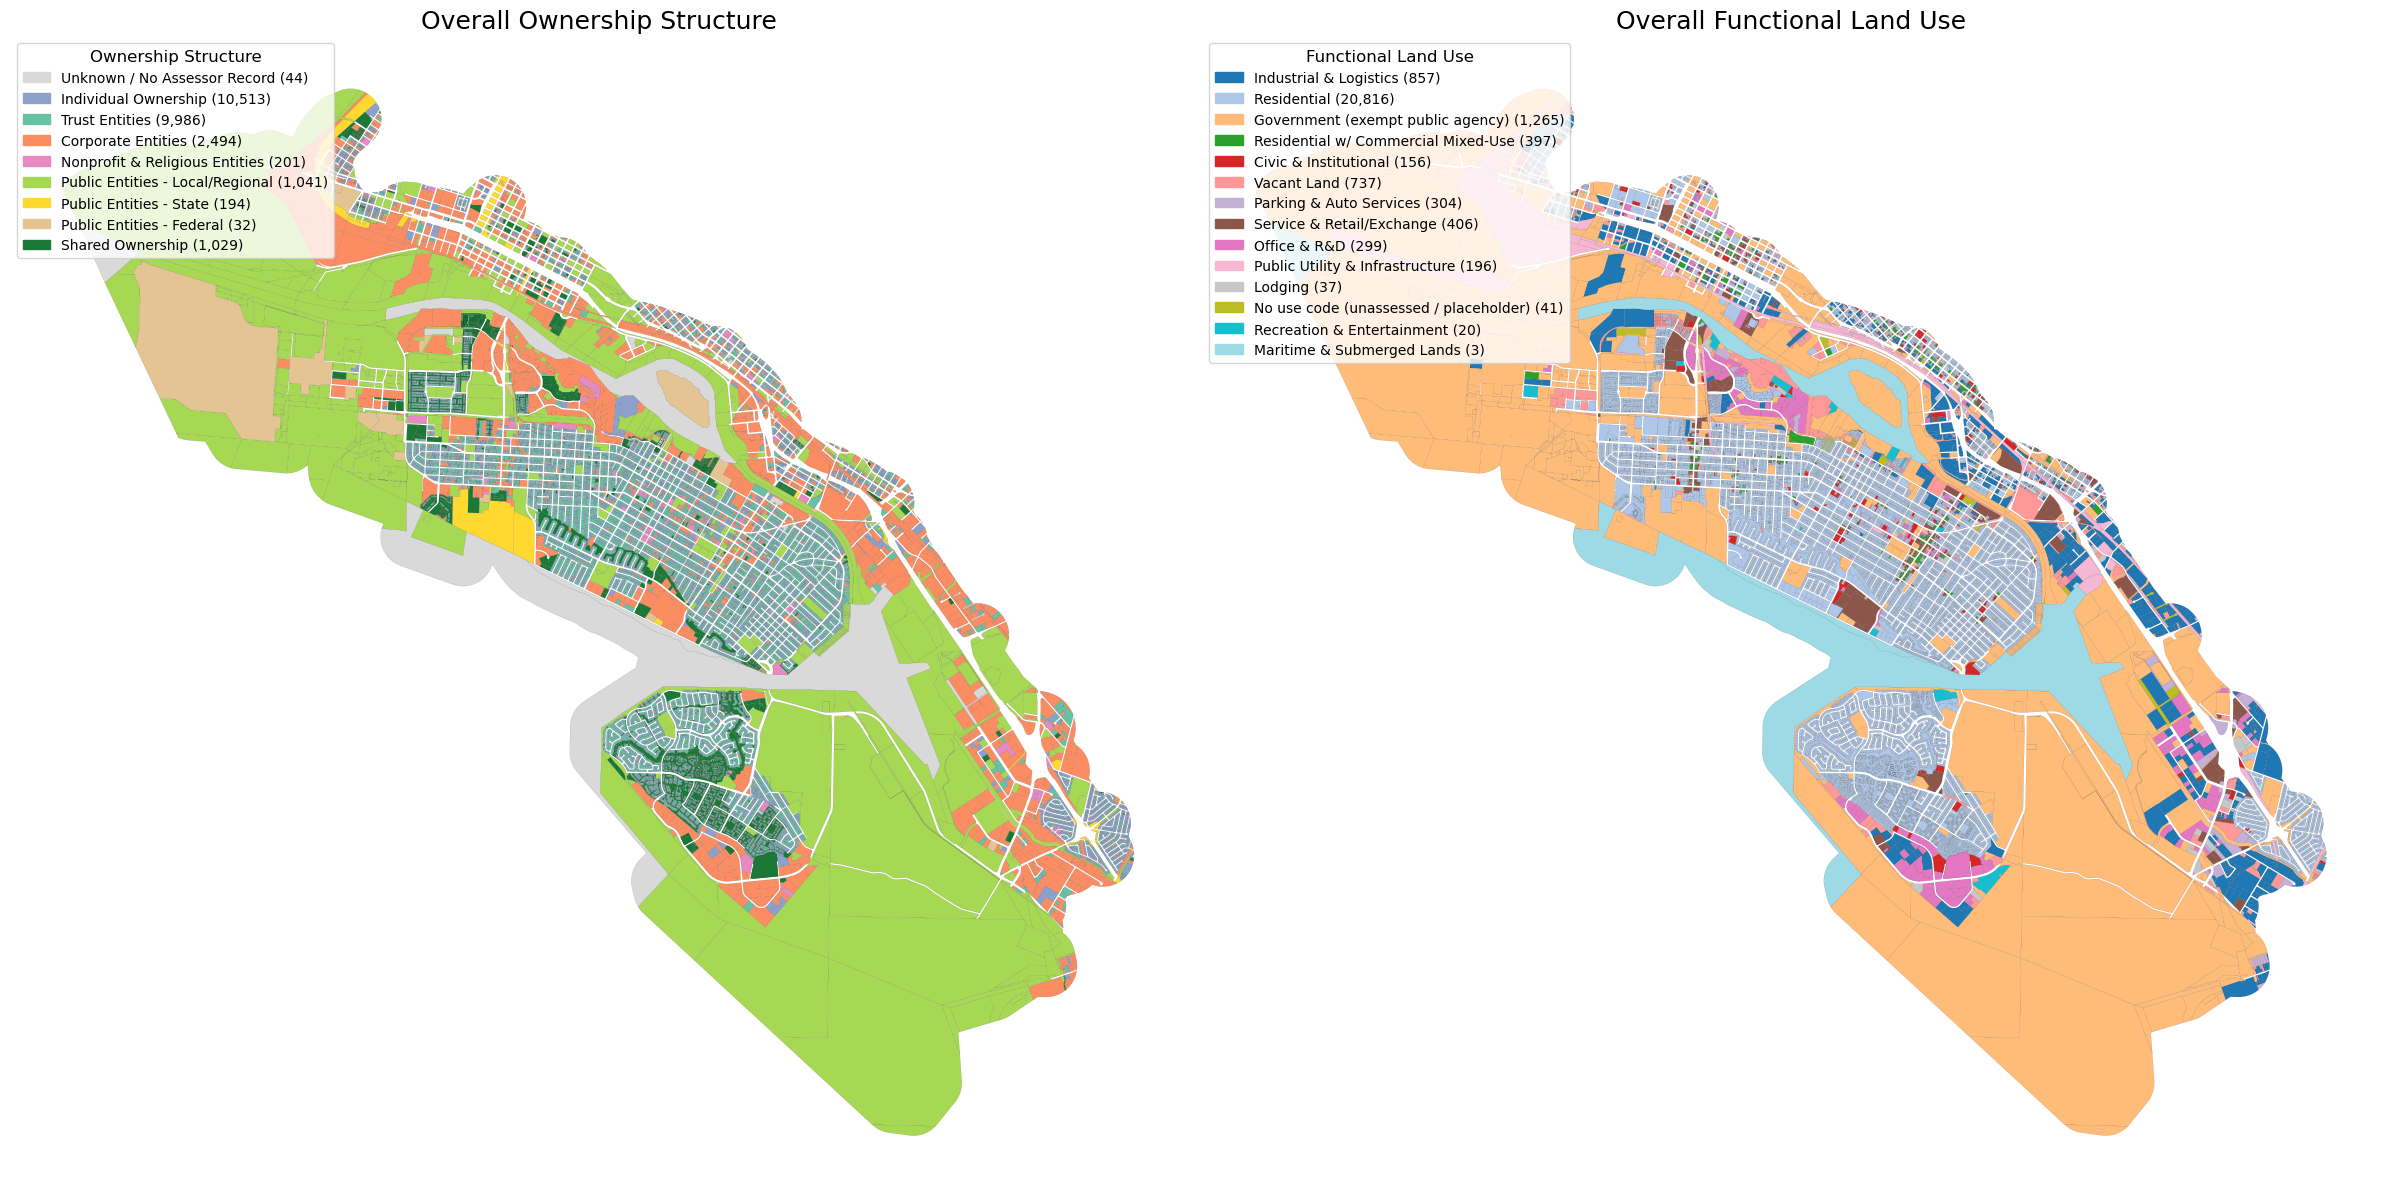


--- Ownership Structure ---
ownership_structure
Individual Ownership                10672
Trust Entities                      10040
Shared Ownership                     7994
Corporate Entities                   2665
Public Entities - Local/Regional     1059
Nonprofit & Religious Entities        219
Public Entities - State               194
Unknown / No Assessor Record           44
Public Entities - Federal              34
Name: count, dtype: int64

--- Land Use Category ---
land_use
Residential                               26983
Government (exempt public agency)          1302
Industrial & Logistics                      885
Vacant Land                                 884
Residential w/ Commercial Mixed-Use         853
Service & Retail/Exchange                   713
Office & R&D                                450
Parking & Auto Services                     308
Public Utility & Infrastructure             196
Civic & Institutional                       158
Maritime & Submerged Lands     

In [1]:
# %% Imports & Dependencies
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from shapely import from_wkb

# Interactive Mapping Imports
import lonboard as lb
from lonboard import Map, PolygonLayer
from lonboard.basemap import MaplibreBasemap, CartoStyle
from lonboard.colormap import apply_categorical_cmap
from palettable.cartocolors.qualitative import Vivid_10
from palettable.cartocolors.qualitative import Pastel_10

# %% Configuration & Constants
GDB_PATH = r"data\raw\alameda_parcel_ownership_20260915.gdb"
GDB_LAYER = "PARCEL_With_Ownership"
EXPECTED_CRS_EPSG = 2227                   
LARGE_PARCEL_SQFT = 1_000_000

REQUIRED_COLUMNS = [
    "apn", "book", "traprimary", "usecode", "ownersname", "totalnetvalue", "hoex",
    "situsstreetnumber", "situsstreetname", "mailingaddressstreet", "mailingaddresscity", "mailingaddressstate",
]

# %% Core Classification Logic
def _has(s: pd.Series, pattern: str) -> pd.Series:
    rx = re.compile(pattern)
    return s.map(lambda x: bool(rx.search(x)))

def blank_to_na(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        if pd.api.types.is_object_dtype(out[c]) or pd.api.types.is_string_dtype(out[c]):
            s = out[c].astype("string")
            out[c] = s.where(s.str.strip().ne(""), pd.NA)
    return out

def get_tenure_and_vacancy(uc_str: str) -> tuple[str, bool]:
    try:
        uc = int(uc_str)
    except ValueError:
        return "unknown", False
        
    is_vacant = uc in [800, 840, 1000, 1040, 3000, 4000, 5000, 5700, 5900, 6000, 7000, 7040, 7090]
    common_areas = [1166, 1190, 1590, 1690, 1890, 3990, 4191, 7090, 7390, 7391, 7392, 7395, 7790]
    
    if uc in common_areas:
        return "common_area", is_vacant
    if uc in [7400, 7430]:
        return "coop", is_vacant
    if (7300 <= uc < 7400) or uc in [3900, 4101, 9401, 9405]:
        return "condo_unit", is_vacant
    if (1500 <= uc < 1700) or (1800 <= uc < 1900):
        return "pud_fee_simple", is_vacant
        
    return "fee_simple", is_vacant

_UTILITY = {400, 500}
_GOVERNMENT = {300, 6001, 6100}
_MARITIME = {9901}
_RECREATION = {6300, 9600, 9700, 9800, 9900, 9905, 9910}
_LODGING = {8900, 9000}
_PARKING_AUTO = {8000, 8100, 8200, 8300, 8400, 8500, 4900}
_MIXED_USE = {1950, 3200, 3705, 4240, 7301, 7302, 7321, 7322, 7341, 7342, 7391, 7392, 7705, 7706}
_OFFICE_RD = {4201, 4202, 4205, 9300, 9400, 9401, 9405, 9491, 9500}
_CIVIC_EXTRA = {8700, 8800, 8801, 8802}
_RES_EXTRA = {600, 700, 750, 900, 940, 5100, 5200, 8901, 9100}
RESIDENTIAL_LAND_USES = ("Residential", "Residential w/ Commercial Mixed-Use")

def land_use_from_code(uc_str: str, is_vacant: bool) -> str:
    try:
        uc = int(uc_str)
    except ValueError:
        return "No use code (unassessed / placeholder)"
        
    if uc in _UTILITY:      return "Public Utility & Infrastructure"
    if uc in _GOVERNMENT:   return "Government (exempt public agency)"
    if uc in _MARITIME:     return "Maritime & Submerged Lands"
    if is_vacant:           return "Vacant Land"
    if uc in _RECREATION:   return "Recreation & Entertainment"
    if uc in _MIXED_USE:    return "Residential w/ Commercial Mixed-Use"
    if uc in _OFFICE_RD:    return "Office & R&D"
    if uc == 6850:          return "Service & Retail/Exchange"        
    if 6000 <= uc < 7000 or uc in _CIVIC_EXTRA: return "Civic & Institutional"
    if uc in _LODGING:      return "Lodging"
    if uc in _PARKING_AUTO: return "Parking & Auto Services"
    if 4000 <= uc < 5000 or uc == 9902: return "Industrial & Logistics"
    if 5300 <= uc < 5900:   return "Rural / Agricultural"
    if 1100 <= uc < 3000 or 7000 <= uc < 8000 or uc in _RES_EXTRA: return "Residential"
    if 3000 <= uc < 4000 or 8000 <= uc < 10000: return "Service & Retail/Exchange"
    return "Other / Unclassified"

def normalize_name(s: pd.Series) -> pd.Series:
    s = s.fillna("").astype(str).str.upper()
    s = s.str.replace(r"[.,'\"]", "", regex=True)
    s = s.str.replace(r"\bCO[- ]?(TR|TRS|TRUSTEES?|TTEES?)\b", "TRS", regex=True)   
    return s.str.replace(r"\s+", " ", regex=True).str.strip()

PUBLIC_RULES: list[tuple[str, str, str]] = [
    ("federal", "US Navy / Dept of Defense", r"^(US NAVY|DEPT OF (THE )?(NAVY|ARMY|AIR FORCE)|DEPARTMENT OF (THE )?(NAVY|ARMY|AIR FORCE|DEFENSE))\b"),
    ("federal", "US Coast Guard", r"^(UNITED STATES )?COAST GUARD\b"),
    ("federal", "US Postal Service", r"^(UNITED STATES POSTAL|US POSTAL|USPS)\b"),
    ("federal", "United States of America", r"^(UNITED STATES(?! (STEEL|CELLULAR|FIRE|GYPSUM|SHIPPING))|US GOVT|US GOVERNMENT|U S GOVT|U S A( ETAL)?$|USA( ETAL)?$|GENERAL SERVICES ADMIN)"),
    ("special_district", "BART", r"RAPID TRANSIT DISTRICT|^BART\b"),
    ("special_district", "AC Transit", r"^(ALAMEDA[- ]?CONTRA COSTA TRANSIT|A ?C TRANSIT DISTRICT)(?! EMPLOYEES)"),
    ("special_district", "EBMUD", r"^(EAST BAY MUNICIPAL UTILITY|EBMUD)"),
    ("special_district", "East Bay Regional Park District", r"^EAST BAY REGIONAL PARK"),
    ("special_district", "Alameda Co. Flood Control District", r"^ALAMEDA (COUNTY|CO) FLOOD"),
    ("special_district", "School district", r"\b(UNIFIED|SCHOOL) DISTRICT\b"),
    ("special_district", "Peralta Community College District", r"^PERALTA (JUNIOR |COMMUNITY )+COLLEGE"),
    ("special_district", "Housing authority", r"HOUSING AUTHORITY|^(CITY )?(OF )?(ALAMEDA|OAKLAND) HOUSING( ETAL)?$|^CITY (OF )?(OAKLAND|ALAMEDA) HOUSING"),
    ("special_district", "Health care district", r"HEALTH CARE DISTRICT"),
    ("special_district", "Port of Oakland", r"^PORT OF OAKLAND"),
    ("special_district", "Joint powers / energy authority", r"^(EAST BAY COMMUNITY ENERGY|NORTHERN CALIFORNIA POWER) AUTHORITY|^NORTHERN CALIFORNIA POWER AGENCY"),
    ("state", "State of California", r"^(STATE OF CALIF|STATE CALIF|CALIFORNIA STATE OF\b|CALIFORNIA STATE LANDS|STATE LANDS COMMISSION|CALTRANS|PEOPLE OF THE STATE)"),
    ("state", "University of California", r"^(REGENTS.*UNIVERSITY.*CALIF|UNIVERSITY OF CALIF)"),
    ("county", "County of Alameda", r"^(COUNTY OF ALAMEDA|ALAMEDA COUNTY(?! (COMMUNITY FOOD|WATER|TRANSPORTATION)))\b"),
    ("city", "City of Alameda", r"^(CITY OF ALAMEDA|CITY ALAMEDA|ALAMEDA CITY OF|COMMUNITY IMPROVEMENT COMMISSION)\b"),
    ("city", "City of Oakland", r"^(CITY OF OAKLAND|CITY OAKLAND|OAKLAND CITY OF|OAKLAND REDEVELOPMENT)\b"),
    ("city", "City of San Leandro / Hayward", r"^CITY (OF )?(SAN LEANDRO|HAYWARD)\b"),
]

LOAN_ASSN_RE = r"\b(SAVINGS (&|AND) LOAN|LOAN ASSOCIATION|NATIONAL ASSOCIATION|MORTGAGE ASSOCIATION)\b"
GENERIC_ASSN_RE = r"\b(ASSN|ASSOC|ASSOCIATION)$"          
ASSOCIATION_RE = (r"\b(HOMEOWNERS?|HOME OWNERS?|OWNERS?|CONDOMINIUMS?|CONDO|TOWNHOUSES?|TOWNHOMES?|COMMUNITY|MAINTENANCE)\b"
                  r".*\b(ASSN|ASSO|ASSOC|ASSOCIATION)\b|\bHOA\b|^COMMON AREA")
NONPROFIT_RE = (r"\b(CHURCH|BAPTIST|CATHOLIC|DIOCESE|SYNAGOGUE|TEMPLE|MOSQUE|CONGREGATION|MINISTR(Y|IES)|LUTHERAN|"
                r"PRESBYTERIAN|METHODIST|EPISCOPAL|BUDDHIST|ASSEMBLY OF GOD|JEHOVAH|SALVATION ARMY|YMCA|YWCA|"
                r"FOUNDATION|CHARIT(Y|IES)|GIRLS INC|FOOD BANK|MUSEUM|HABITAT FOR HUMANITY|FAMILY SERVICES|HOSPICE|"
                r"AFFORDABLE HOUSING (CORP|CORPORATION)|ALLIANCE FOR HEALTH|FIRST 5|SCHOOL|ACADEMY|"
                r"CLUB|SOCIETY|GUILD|CHAPEL|CHABAD|RELIGION|COLLABORATIVE)\b")
BUSINESS_RE = (r"\bL L C$|\b(LLC|LLP|LP|LTD|INC|INCORPORATED|CORP|CORPORATION|COMPANY|CO|PARTNERS|PARTNERSHIP|ASSOCIATES|"
               r"HOLDINGS?|PROPERTIES|PROPERTY|INVESTMENTS?|INVESTORS|VENTURES?|ENTERPRISES?|REALTY|DEVELOPMENTS?|"
               r"DEVELOPERS|CAPITAL|GROUP|FUND|BANK|MORTGAGE|FINANCIAL|EQUITIES|INDUSTRIES|LEASING|MANAGEMENT|"
               r"BUILDERS|APARTMENTS|HOMES)\b")
TRUST_RE = r"\b(TRUST|TRUSTS|TR|TRS|TRUSTEE|TRUSTEES|TTEE|TTEES|TSTEE|TSTEES|TRST)\b"
ESTATE_RE = r"\b(ESTATE OF|EST OF|HEIRS OF)\b|\bESTATE$"

def classify_owner(names: pd.Series, usecodes: pd.Series) -> pd.DataFrame:
    n = normalize_name(names)
    idx = n.index
    form = pd.Series("", index=idx, dtype=object)
    basis = pd.Series("", index=idx, dtype=object)
    level = pd.Series(pd.NA, index=idx, dtype=object)
    agency = pd.Series(pd.NA, index=idx, dtype=object)

    def assign(mask, f, b):
        m = mask & (form == "")
        form[m] = f
        basis[m] = b
        return m

    assign(n == "", "unknown", "blank owner name")
    for lvl, ag, pat in PUBLIC_RULES:
        m = assign(_has(n, pat), "public", f"name:{ag}")
        level[m] = lvl
        agency[m] = ag
    assign(_has(n, LOAN_ASSN_RE), "business", "name:bank / savings & loan")   
    assign(_has(n, ASSOCIATION_RE) | _has(n, GENERIC_ASSN_RE), "association", "name:HOA/association")
    assign(_has(n, NONPROFIT_RE), "nonprofit_religious", "name:nonprofit/religious")
    assign(_has(n, BUSINESS_RE), "business", "name:business suffix/keyword")
    assign(_has(n, TRUST_RE), "trust", "name:trust marker")
    assign(_has(n, ESTATE_RE), "estate", "name:estate")
    uc = usecodes.fillna("")                                            
    m = assign(uc.isin(["0300", "6001", "6100"]), "public", "usecode:exempt/government, agency unresolved")
    level[m] = "unresolved"
    assign(uc.isin(["0400", "0500"]), "utility", "usecode:utility")
    assign(pd.Series(True, index=idx), "individual", "default: no organisational marker")   
    return pd.DataFrame({"owner_form": form, "public_level": level, "public_agency": agency,
                         "owner_form_basis": basis, "owner_name_norm": n})

PUBLIC_LABEL = {"federal": "Public Entities - Federal", "state": "Public Entities - State",
                "county": "Public Entities - Local/Regional", "city": "Public Entities - Local/Regional",
                "special_district": "Public Entities - Local/Regional", "unresolved": "Public Entities - Unresolved"}

def ownership_structure(owner_form: pd.Series, public_level: pd.Series, tenure: pd.Series) -> pd.Series:
    s = pd.Series("Individual Ownership", index=owner_form.index, dtype=object)
    s[owner_form == "unknown"] = "Unknown / No Assessor Record"
    s[owner_form == "nonprofit_religious"] = "Nonprofit & Religious Entities"
    s[owner_form.isin(["business", "utility"])] = "Corporate Entities"
    s[owner_form == "trust"] = "Trust Entities"
    shared = tenure.isin(["condo_unit", "common_area", "coop"]) | (owner_form == "association")
    s[shared & (owner_form != "public")] = "Shared Ownership"        
    pub = owner_form == "public"
    s[pub] = public_level[pub].map(PUBLIC_LABEL)
    return s

def add_occupancy_and_locality(df: pd.DataFrame, residential_mask: pd.Series) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    hoex = df["hoex"].fillna(0)
    oo = pd.Series(pd.NA, index=df.index, dtype="boolean")
    oo[residential_mask] = (hoex > 0)[residential_mask]
    out["owner_occupied_hoex"] = oo

    _STREET_SUFFIX = {"AVENUE": "AVE", "AV": "AVE", "STREET": "ST", "BOULEVARD": "BLVD", "ROAD": "RD", "DRIVE": "DR"}
    def normalize_street(s: pd.Series) -> pd.Series:
        s = s.fillna("").astype(str).str.upper().str.replace(r"[.,#']", "", regex=True).str.replace(r"\s+", " ", regex=True).str.strip()
        s = s.str.replace(r"\s(STE|SUITE|UNIT|APT|APARTMENT|SPC|SPACE|BLDG|FL|FLOOR)\s.*$", "", regex=True)
        return s.map(lambda x: " ".join(_STREET_SUFFIX.get(t, t) for t in x.split(" ")))

    sit = normalize_street(df["situsstreetnumber"].astype("string").fillna("") + " " + df["situsstreetname"].fillna(""))
    mail = normalize_street(df["mailingaddressstreet"])
    on_site = ((sit == mail) & sit.str.match(r"^\d")).astype(bool)
    city = df["mailingaddresscity"].astype("string").str.upper().str.strip()
    state = df["mailingaddressstate"].astype("string").str.upper().str.strip()
    
    b = lambda x: x.fillna(False).to_numpy(dtype=bool)
    in_alameda = b((city == "ALAMEDA") & (state == "CA"))
    
    out["owner_on_site"] = on_site
    out["registration_type"] = np.select([b(city.isna() | state.isna()), in_alameda],
                                         ["Unknown", "Locally Registered"], default="Externally Registered")
    return out

# %% Pipeline Execution & Data Generation
print("Loading geodatabase...")
gdf = gpd.read_file(GDB_PATH, layer=GDB_LAYER)

# Validate columns
missing = [c for c in REQUIRED_COLUMNS if c not in gdf.columns]
if missing:
    raise KeyError(f"Required columns missing: {missing}")

gdf = blank_to_na(gdf)
gdf["usecode"] = gdf["usecode"].astype("string").str.strip().str.zfill(4).where(gdf["usecode"].notna())
area_sqft = gdf.geometry.area

print("Applying analytical categorizations...")
# 1. Broadening scope: Processing entire geodatabase without filtering boundaries
gdf["is_large_exempt"] = (area_sqft > LARGE_PARCEL_SQFT) & (gdf["totalnetvalue"].fillna(0) == 0)

# 2. Tenure & Land Use
tenure_vac = gdf["usecode"].apply(lambda x: get_tenure_and_vacancy(x) if pd.notna(x) else ("unknown", False))
gdf["tenure_structure"] = [t[0] for t in tenure_vac]
gdf["is_vacant"] = [t[1] for t in tenure_vac]
gdf["land_use"] = gdf.apply(lambda row: land_use_from_code(row["usecode"], row["is_vacant"]) if pd.notna(row["usecode"]) else "No use code (unassessed / placeholder)", axis=1)

# Water Proxies
gdf.loc[gdf["is_large_exempt"] & gdf["usecode"].isna(), "land_use"] = "Maritime & Submerged Lands"
gdf['water_dependent'] = gdf['is_large_exempt'] | gdf["usecode"].isin(['0750', '4700', '9901'])

# 3. Ownership
owners_df = classify_owner(gdf["ownersname"], gdf["usecode"])
gdf = gdf.join(owners_df)
gdf["ownership_structure"] = ownership_structure(gdf["owner_form"], gdf["public_level"], gdf["tenure_structure"])

# 4. Occupancy / Locality
res_mask = gdf["land_use"].isin(RESIDENTIAL_LAND_USES)
gdf = gdf.join(add_occupancy_and_locality(gdf, res_mask))

# 5. Handle Stacked Geometries for Static Rendering
print("Cleaning geometries for static mapping...")
key = gdf.geometry.to_wkb()
pri = (gdf["ownership_structure"] == "Shared Ownership").astype(int)
map_gdf = gdf.assign(_pri=pri, _key=key).sort_values("_pri", ascending=False).drop_duplicates("_key")
map_gdf = map_gdf.sort_values("_pri", ascending=True).drop(columns=["_pri", "_key"]) # Sort ascending so shared draws ON TOP

# 6. Save Parquet
output_path = Path("data") / "cleaned" / "alameda_master_full.parquet"
output_path.parent.mkdir(parents=True, exist_ok=True)
gdf.drop(columns=['owner_name_norm']).to_parquet(output_path, index=False)
print(f"Data saved to {output_path}")

# %% Static Matplotlib Rendering
print("Rendering static maps...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))

# Map 1: Ownership Structure
OWNERSHIP_COLORS = {
    "Unknown / No Assessor Record": "#d9d9d9", "Individual Ownership": "#8da0cb", "Trust Entities": "#66c2a5",
    "Corporate Entities": "#fc8d62", "Nonprofit & Religious Entities": "#e78ac3",
    "Public Entities - Local/Regional": "#a6d854", "Public Entities - State": "#ffd92f",
    "Public Entities - Federal": "#e5c494", "Public Entities - Unresolved": "#b3b3b3", "Shared Ownership": "#1b7837"
}

handles1 = []
for cat, col in OWNERSHIP_COLORS.items():
    sub = map_gdf[map_gdf["ownership_structure"] == cat]
    if len(sub):
        sub.plot(ax=ax1, color=col, edgecolor="black", linewidth=0.05)
        handles1.append(mpatches.Patch(color=col, label=f"{cat} ({len(sub):,})"))

ax1.legend(handles=handles1, loc="upper left", title="Ownership Structure", title_fontsize=12, fontsize=10)
ax1.set_title("Overall Ownership Structure", fontsize=18)
ax1.set_axis_off()

# Map 2: Land Use
cmap = plt.get_cmap('tab20', len(map_gdf['land_use'].unique()))
land_use_colors = {cat: cmap(i) for i, cat in enumerate(map_gdf['land_use'].unique())}

handles2 = []
for cat, col in land_use_colors.items():
    sub = map_gdf[map_gdf["land_use"] == cat]
    if len(sub):
        sub.plot(ax=ax2, color=col, edgecolor="black", linewidth=0.05)
        handles2.append(mpatches.Patch(color=col, label=f"{cat} ({len(sub):,})"))

ax2.legend(handles=handles2, loc="upper left", title="Functional Land Use", title_fontsize=12, fontsize=10)
ax2.set_title("Overall Functional Land Use", fontsize=18)
ax2.set_axis_off()

plt.tight_layout()
plt.show()

# Print Summaries
print("\n--- Ownership Structure ---")
print(gdf['ownership_structure'].value_counts())
print("\n--- Land Use Category ---")
print(gdf['land_use'].value_counts())


# %% Interactive Lonboard Mapping
print("\nConfiguring Interactive Web Map...")

# Define columns to keep, ensuring 'geometry' is retained for spatial mapping
columns_to_keep = [
    'apn_accela_format', 'totalnetvalue', 'ownersname', 'usecode', 'lotsize', 
    'buildings', 'stories', 'rooms', 'beds', 'acre', 
    'landtype', 'yearbuilt', 'condo', 'mailingaddress', 'tenure_structure', 
    'is_vacant', 'land_use', 'water_dependent', 'owner_form', 'owner_form_basis', 
    'public_level', 'public_agency', 'ownership_structure', 'registration_type',
    'geometry'
]

# Verify all expected columns exist to fail loudly if data is missing
missing_cols = [c for c in columns_to_keep if c not in gdf.columns]
if missing_cols:
    raise KeyError(f"Required columns missing from dataframe: {missing_cols}")

# Trim the dataframe to the condensed parameter list
gdf_clean = gdf[columns_to_keep].copy()

# Drop rows without valid geometries to prevent mapping errors
gdf_clean = gdf_clean.dropna(subset=['geometry'])

# 1. Cast back to a GeoDataFrame to restore spatial attributes 
if not isinstance(gdf_clean, gpd.GeoDataFrame):
    if isinstance(gdf_clean['geometry'].iloc[0], bytes):
        gdf_clean['geometry'] = gdf_clean['geometry'].apply(from_wkb)
    gdf_clean = gpd.GeoDataFrame(gdf_clean, geometry='geometry')

# 2. Ensure the initial CRS is set before reprojection
if gdf_clean.crs is None:
    gdf_clean = gdf_clean.set_crs(epsg=EXPECTED_CRS_EPSG)

# 3. Reproject to WGS84 for web mapping
if gdf_clean.crs != "EPSG:4326":
    gdf_clean = gdf_clean.to_crs(epsg=4326)

# Standardize missing text values to prevent tooltip/rendering errors
for col in gdf_clean.select_dtypes(['object', 'string']).columns:
    gdf_clean[col] = gdf_clean[col].fillna("Unknown")

# Helper function to generate robust categorical color mappings
def create_color_mapping(geo_df, column_name):
    categories = geo_df[column_name].astype("string")
    unique_cats = pd.Index(pd.unique(categories))
    
    # Utilizing Pastel_10 qualitative palette from palettable
    palette_colors = (np.array(Pastel_10.mpl_colors) * 255).astype(np.uint8)
    
    color_mapping = {
        cat: palette_colors[i % len(palette_colors)].tolist() 
        for i, cat in enumerate(unique_cats)
    }
    
    cat_dtype = categories.astype(pd.CategoricalDtype(categories=unique_cats))
    
    # Setting alpha=75 provides transparency to view the basemap
    return apply_categorical_cmap(cat_dtype, color_mapping, alpha=75)

# Generate color arrays for both target layers
ownership_colors_lb = create_color_mapping(gdf_clean, "ownership_structure")
land_use_colors_lb = create_color_mapping(gdf_clean, "land_use")

# Create the Ownership Structure Layer
ownership_layer = PolygonLayer.from_geopandas(
    gdf_clean,
    get_fill_color=ownership_colors_lb,
    get_line_color=[40, 40, 40, 100],
    line_width_min_pixels=0.5,
    extruded=False,
    auto_highlight=True,
    highlight_color=[255, 255, 255, 200]
)

# Create the Land Use Layer
land_use_layer = PolygonLayer.from_geopandas(
    gdf_clean,
    get_fill_color=land_use_colors_lb,
    get_line_color=[40, 40, 40, 100],
    line_width_min_pixels=0.5,
    extruded=False,
    auto_highlight=True,
    highlight_color=[255, 255, 255, 200]
)

# Render interactive map
m = Map(
    layers=[ownership_layer, land_use_layer],
    basemap=MaplibreBasemap(style=CartoStyle.Positron),
    view_state={
        "longitude": -122.2711, 
        "latitude": 37.7652, 
        "zoom": 12, 
        "pitch": 0
    }
)

# Export to standalone HTML file
output_html = './alameda_interactive_map.html'
m.to_html(output_html, title="Alameda Parcel Map")
print(f"Interactive map exported to: {output_html}")

# Display inline
m

In [2]:
import ipywidgets as W
from typing import Iterable, Mapping

def legend_for_cmap(cats: Iterable, cmap: Mapping[str, list[int]], title: str = "Legend") -> W.HTML:
    def _rgb_to_hex(rgb: list[int]) -> str:
        r, g, b = (int(rgb[0]), int(rgb[1]), int(rgb[2]))
        return f"#{r:02x}{g:02x}{b:02x}"

    items = []
    for k in map(str, cats):
        hexcol = _rgb_to_hex(cmap[k])
        items.append(
            f'''<div class="item">
                   <span class="swatch" style="background:{hexcol}"></span>
                   <span class="label">{k}</span>
                </div>'''
        )

    html = f"""
    <style>
      .lb-legend {{
        background: #ffffff;
        border: 1px solid #00000015;
        border-radius: 12px;
        padding: 10px 14px;
        font: 12px system-ui, -apple-system, sans-serif;
        color: #444;
        box-shadow: 0 4px 12px rgba(0, 0, 0, 0.08);
        max-width: 100%;
        margin-bottom: 8px;
      }}
      .lb-legend .title {{
        font-weight: 700;
        margin-bottom: 8px;
        color: #222;
        text-transform: uppercase;
        letter-spacing: 0.02em;
        font-size: 11px;
      }}
      .lb-legend .grid {{
        display: grid;
        grid-template-columns: repeat(auto-fill, minmax(130px, 1fr));
        gap: 6px 12px;
      }}
      .lb-legend .item {{ display: flex; align-items: center; }}
      .lb-legend .swatch {{
        width: 10px; height: 10px;
        border: 1px solid #0002;
        border-radius: 3px;
        margin-right: 8px;
        flex-shrink: 0;
      }}
      .lb-legend .label {{
        white-space: nowrap;
        overflow: hidden;
        text-overflow: ellipsis;
      }}
    </style>
    <div class="lb-legend">
      <div class="title">{title}</div>
      <div class="grid">
        {''.join(items)}
      </div>
    </div>
    """
    return W.HTML(value=html)

In [3]:
def create_color_mapping(geo_df, column_name):
    categories = geo_df[column_name].astype("string")
    unique_cats = pd.Index(pd.unique(categories))
    
    palette_colors = (np.array(Vivid_10.mpl_colors) * 255).astype(np.uint8)
    
    color_mapping = {
        cat: palette_colors[i % len(palette_colors)].tolist() 
        for i, cat in enumerate(unique_cats)
    }
    
    cat_dtype = categories.astype(pd.CategoricalDtype(categories=unique_cats))
    color_array = apply_categorical_cmap(cat_dtype, color_mapping, alpha=110)
    
    # Return all three elements so the legend can use them
    return color_array, unique_cats, color_mapping

# Generate arrays and mapping dictionaries for your layers
ownership_colors_lb, own_cats, own_cmap = create_color_mapping(gdf_clean, "ownership_structure")
land_use_colors_lb, lu_cats, lu_cmap = create_color_mapping(gdf_clean, "land_use")

In [4]:
# Create the legend widget for Ownership Structure
legend = legend_for_cmap(own_cats, own_cmap, title="Ownership Structure")

# Render the legend stacked on top of the map in the notebook cell
W.VBox([legend, m])

In [5]:
# Export to standalone HTML file
output_html = './alameda_interactive_map.html'
m.to_html(output_html, title="Alameda Parcel Map")
print(f"Interactive map exported to: {output_html}")

# Export the cleaned and reprojected spatial dataset to Parquet
output_parquet = './CP248_Ownership_LandUse_PropertyInfo.parquet'
gdf_clean.to_parquet(output_parquet, index=False)
print(f"Cleaned spatial dataset exported to: {output_parquet}")

# Display inline
W.VBox([legend, m])

Interactive map exported to: ./alameda_interactive_map.html
Cleaned spatial dataset exported to: ./CP248_Ownership_LandUse_PropertyInfo.parquet
